In [1]:
# eda_thresholds.py
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pipeline  # Importing our custom module

# 1. Load the data via our pipeline module
df = pipeline.fetch_and_prepare_data(force_refresh=False)

# Define 'Future Realized Volatility' proxy for visualization
df['Future_Sq_Return'] = df['Sq_Log_Return'].shift(-1)
df = df.dropna()

Loading cached processed master data from data/processed_master_data.parquet...


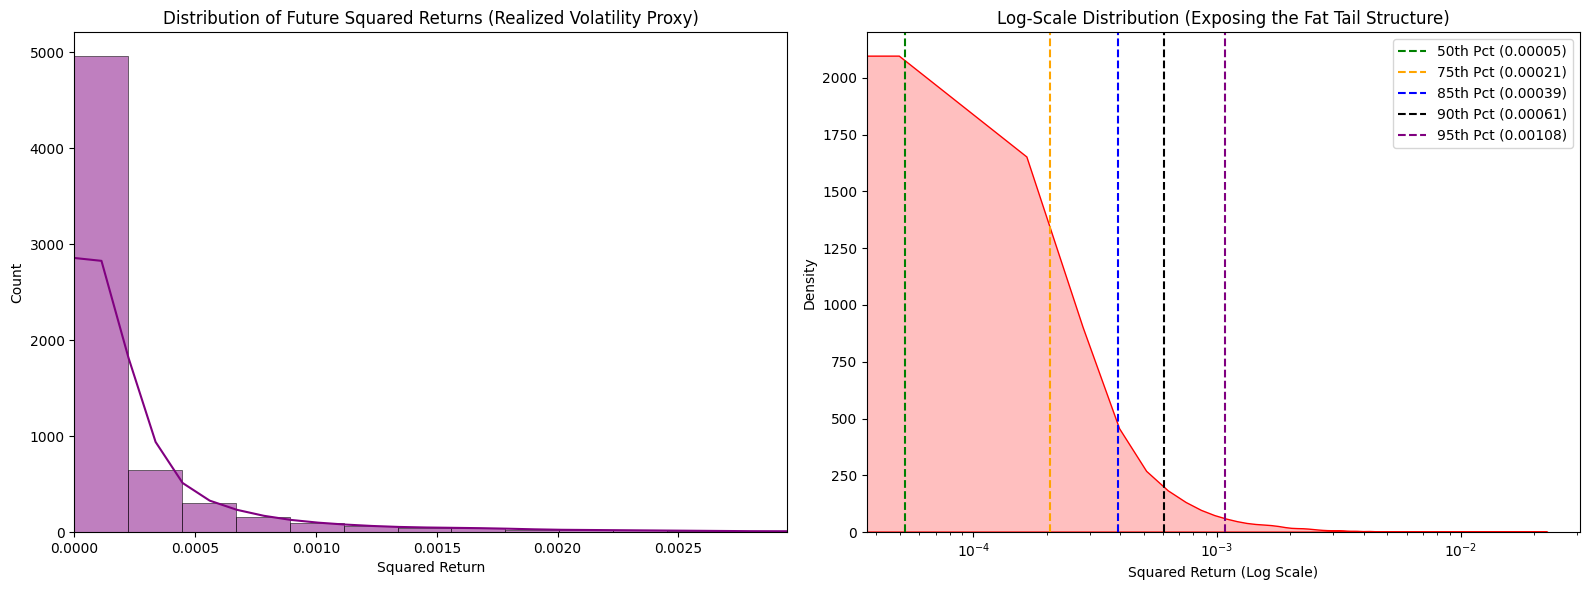

In [2]:
# ---------------------------------------------------------
# VISUAL 1: Kernel Density Estimate (KDE) & Log-Scale Tail Analysis
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Standard distribution plot
sns.histplot(df['Future_Sq_Return'], bins=100, kde=True, ax=axes[0], color='purple')
axes[0].set_title("Distribution of Future Squared Returns (Realized Volatility Proxy)")
axes[0].set_xlabel("Squared Return")
axes[0].set_xlim(0, df['Future_Sq_Return'].quantile(0.99)) # Clip extreme outlier for viewing

# Log-scale distribution to expose the "Fat Tail" regimes
sns.kdeplot(df['Future_Sq_Return'], ax=axes[1], color='red', fill=True)
axes[1].set_xscale('log')
axes[1].set_title("Log-Scale Distribution (Exposing the Fat Tail Structure)")
axes[1].set_xlabel("Squared Return (Log Scale)")

# Let's map potential boundaries on the log plot to see where structural changes happen
p50 = df['Future_Sq_Return'].quantile(0.50)
p75 = df['Future_Sq_Return'].quantile(0.75)
p85 = df['Future_Sq_Return'].quantile(0.85)
p90 = df['Future_Sq_Return'].quantile(0.90)
p95 = df['Future_Sq_Return'].quantile(0.95)

axes[1].axvline(p50, color='green', linestyle='--', label=f'50th Pct ({p50:.5f})')
axes[1].axvline(p75, color='orange', linestyle='--', label=f'75th Pct ({p75:.5f})')
axes[1].axvline(p85, color='blue', linestyle='--', label=f'85th Pct ({p85:.5f})')
axes[1].axvline(p90, color='black', linestyle='--', label=f'90th Pct ({p90:.5f})')
axes[1].axvline(p95, color='purple', linestyle='--', label=f'95th Pct ({p95:.5f})')
axes[1].legend()

plt.tight_layout()
plt.show()


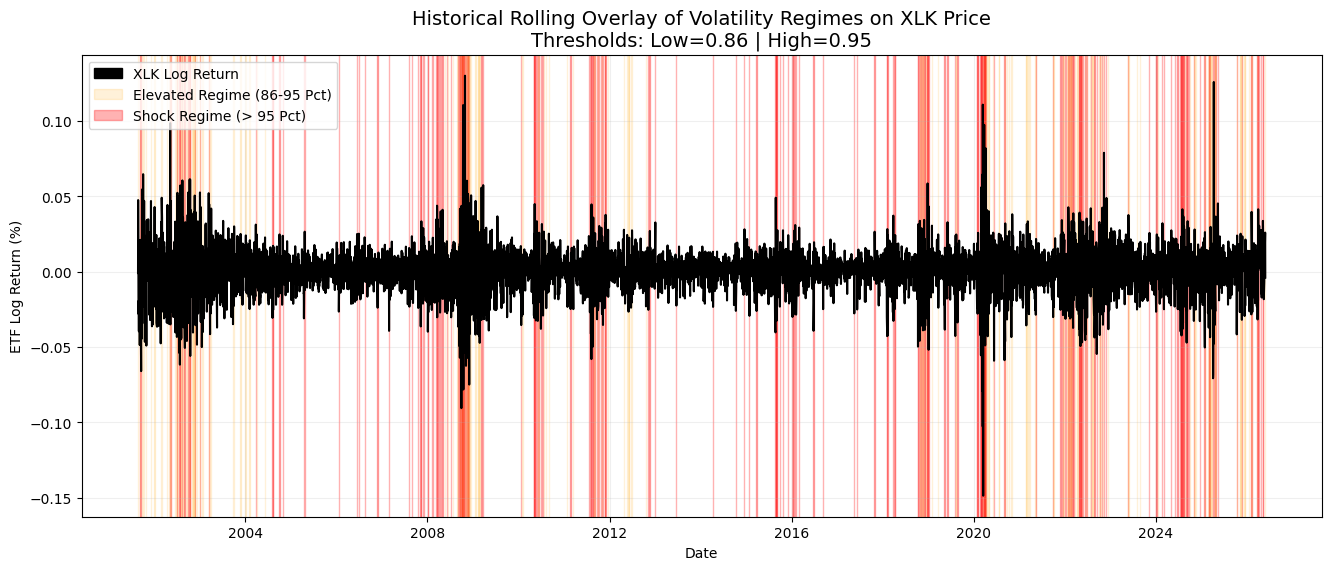

In [2]:
# ---------------------------------------------------------
# VISUAL 2: Historical Regime Overlay Analysis
# ---------------------------------------------------------
# Let's test custom prospective thresholds to visually check their historical validity
# Test Config: Lower Threshold = 60th percentile, Upper Threshold = 88th percentile
LOWER_QUANT = 0.86
UPPER_QUANT = 0.95
#WINDOW = 252 # default 252
#FLOOR = 0.0005 # default 0.0005

df_regimes= pipeline.create_multiclass_target(df, LOWER_QUANT, UPPER_QUANT)

plt.figure(figsize=(16, 6))
plt.plot(df_regimes.index, df_regimes['Log_Return'], color='black', linewidth=1.5, label='XLK Close Price')

# Dynamic background highlighting based on designated regimes
# 0 = Calm (No color), 1 = Elevated (Yellow), 2 = Shock (Red)
# To speed up rendering, we find blocks of regimes
diff = df_regimes['Target_Regime'].diff().fillna(0)
regime_changes = df_regimes[diff != 0].index.tolist()
regime_changes.insert(0, df_regimes.index[0])
regime_changes.append(df_regimes.index[-1])

for i in range(len(regime_changes)-1):
    start = regime_changes[i]
    end = regime_changes[i+1]
    current_regime = df_regimes.loc[start, 'Target_Regime']
    
    if current_regime == 1:
        plt.axvspan(start, end, color='orange', alpha=0.15)
    elif current_regime == 2:
        plt.axvspan(start, end, color='red', alpha=0.3)

# Creating custom proxy legends for colors
import matplotlib.patches as mpatches
orange_patch = mpatches.Patch(color='orange', alpha=0.15, label=f'Elevated Regime ({int(LOWER_QUANT*100)}-{int(UPPER_QUANT*100)} Pct)')
red_patch = mpatches.Patch(color='red', alpha=0.3, label=f'Shock Regime (> {int(UPPER_QUANT*100)} Pct)')

plt.legend(handles=[mpatches.Patch(color='black', label='XLK Log Return'), orange_patch, red_patch], loc='upper left')
plt.title(f"Historical Rolling Overlay of Volatility Regimes on XLK Price\nThresholds: Low={LOWER_QUANT} | High={UPPER_QUANT}", fontsize=14)
plt.ylabel("ETF Log Return (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.2)
plt.show()


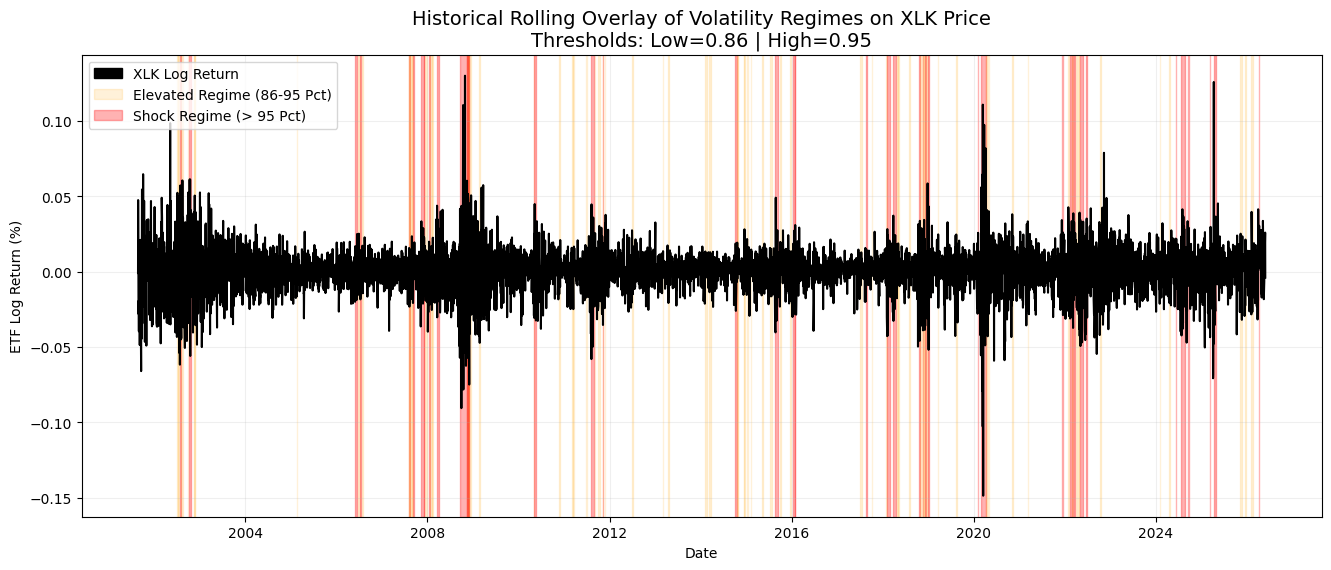

In [6]:
# ---------------------------------------------------------
# VISUAL 2: Historical Regime Overlay Analysis
# ---------------------------------------------------------
# Let's test custom prospective thresholds to visually check their historical validity
# Test Config: Lower Threshold = 60th percentile, Upper Threshold = 88th percentile
LOWER_QUANT = 0.86
UPPER_QUANT = 0.95
#WINDOW = 252 # default 252
#FLOOR = 0.0005 # default 0.0005

df_regimes= pipeline.create_multiclass_target(df, LOWER_QUANT, UPPER_QUANT, floor=0, shock_smooth=3, elevated_smooth=3)

plt.figure(figsize=(16, 6))
plt.plot(df_regimes.index, df_regimes['Log_Return'], color='black', linewidth=1.5, label='XLK Close Price')

# Dynamic background highlighting based on designated regimes
# 0 = Calm (No color), 1 = Elevated (Yellow), 2 = Shock (Red)
# To speed up rendering, we find blocks of regimes
diff = df_regimes['Target_Smooth_10d'].diff().fillna(0)
regime_changes = df_regimes[diff != 0].index.tolist()
regime_changes.insert(0, df_regimes.index[0])
regime_changes.append(df_regimes.index[-1])

for i in range(len(regime_changes)-1):
    start = regime_changes[i]
    end = regime_changes[i+1]
    current_regime = df_regimes.loc[start, 'Target_Smooth_10d']
    
    if current_regime == 1:
        plt.axvspan(start, end, color='orange', alpha=0.15)
    elif current_regime == 2:
        plt.axvspan(start, end, color='red', alpha=0.3)

# Creating custom proxy legends for colors
import matplotlib.patches as mpatches
orange_patch = mpatches.Patch(color='orange', alpha=0.15, label=f'Elevated Regime ({int(LOWER_QUANT*100)}-{int(UPPER_QUANT*100)} Pct)')
red_patch = mpatches.Patch(color='red', alpha=0.3, label=f'Shock Regime (> {int(UPPER_QUANT*100)} Pct)')

plt.legend(handles=[mpatches.Patch(color='black', label='XLK Log Return'), orange_patch, red_patch], loc='upper left')
plt.title(f"Historical Rolling Overlay of Volatility Regimes on XLK Price\nThresholds: Low={LOWER_QUANT} | High={UPPER_QUANT}", fontsize=14)
plt.ylabel("ETF Log Return (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.2)
plt.show()


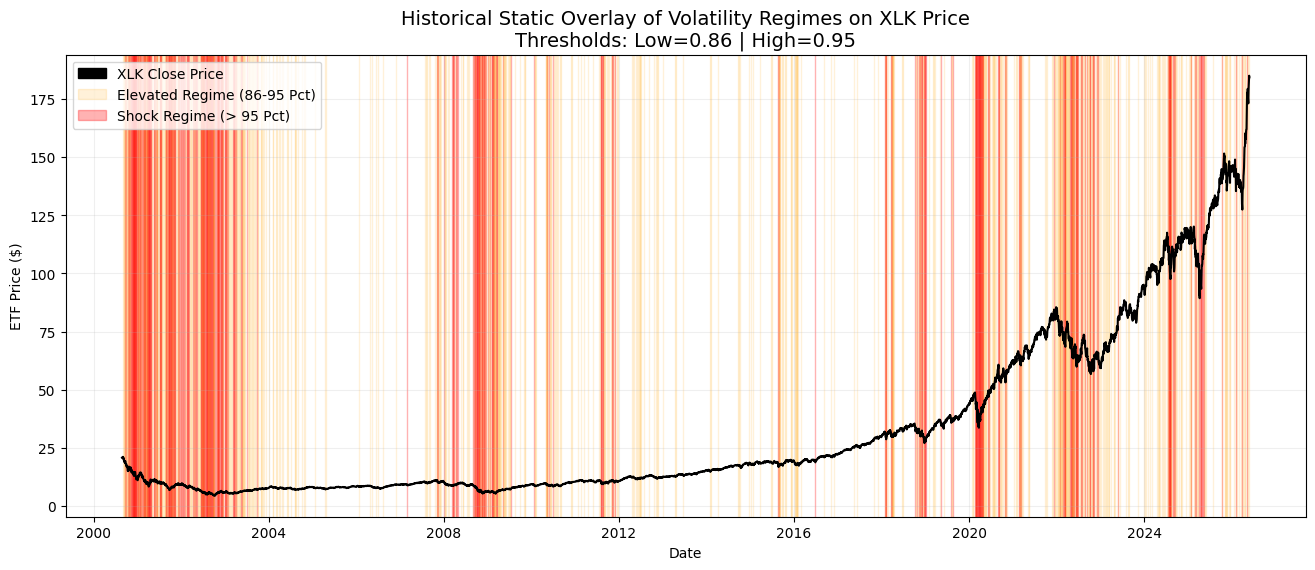

In [4]:
# ---------------------------------------------------------
# VISUAL 2: Historical Regime Overlay Analysis
# ---------------------------------------------------------
# Let's test custom prospective thresholds to visually check their historical validity
# Test Config: Lower Threshold = 60th percentile, Upper Threshold = 88th percentile
LOWER_QUANT = 0.86
UPPER_QUANT = 0.95

df_regimes, t_low, t_high= pipeline.create_static_multiclass_target(df, LOWER_QUANT, UPPER_QUANT)

plt.figure(figsize=(16, 6))
plt.plot(df_regimes.index, df_regimes['Close'], color='black', linewidth=1.5, label='XLK Close Price')

# Dynamic background highlighting based on designated regimes
# 0 = Calm (No color), 1 = Elevated (Yellow), 2 = Shock (Red)
# To speed up rendering, we find blocks of regimes
diff = df_regimes['Target_Regime'].diff().fillna(0)
regime_changes = df_regimes[diff != 0].index.tolist()
regime_changes.insert(0, df_regimes.index[0])
regime_changes.append(df_regimes.index[-1])

for i in range(len(regime_changes)-1):
    start = regime_changes[i]
    end = regime_changes[i+1]
    current_regime = df_regimes.loc[start, 'Target_Regime']
    
    if current_regime == 1:
        plt.axvspan(start, end, color='orange', alpha=0.15)
    elif current_regime == 2:
        plt.axvspan(start, end, color='red', alpha=0.3)

# Creating custom proxy legends for colors
import matplotlib.patches as mpatches
orange_patch = mpatches.Patch(color='orange', alpha=0.15, label=f'Elevated Regime ({int(LOWER_QUANT*100)}-{int(UPPER_QUANT*100)} Pct)')
red_patch = mpatches.Patch(color='red', alpha=0.3, label=f'Shock Regime (> {int(UPPER_QUANT*100)} Pct)')

plt.legend(handles=[mpatches.Patch(color='black', label='XLK Close Price'), orange_patch, red_patch], loc='upper left')
plt.title(f"Historical Static Overlay of Volatility Regimes on XLK Price\nThresholds: Low={LOWER_QUANT} | High={UPPER_QUANT}", fontsize=14)
plt.ylabel("ETF Price ($)")
plt.xlabel("Date")
plt.grid(True, alpha=0.2)
plt.show()


In [5]:
# ---------------------------------------------------------
# Descriptive Statistics of Shocks
# ---------------------------------------------------------
print("\n" + "="*40)
print("Statistical Properties of Identified Regimes")
print("="*40)
for regime in [0, 1, 2]:
    subset = df_regimes[df_regimes['Target_Regime'] == regime]
    name = "Calm" if regime == 0 else "Elevated" if regime == 1 else "Shock"
    print(f"\n[{name} Regime - Class {regime}]")
    print(f"  Total Days:             {len(subset)}")
    print(f"  Average EGARCH Vol:     {subset['Vol_EGARCH'].mean():.4f}")
    print(f"  Max Realized Shock:     {subset['Future_Sq_Return'].max():.6f}")
    print(f"  Avg Daily VIX Change:   {subset['VIX_Change'].mean()*100:.2f}%")


Statistical Properties of Identified Regimes

[Calm Regime - Class 0]
  Total Days:             5364
  Average EGARCH Vol:     1.2792
  Max Realized Shock:     0.002164
  Avg Daily VIX Change:   0.10%

[Elevated Regime - Class 1]
  Total Days:             493
  Average EGARCH Vol:     1.5512
  Max Realized Shock:     0.004195
  Avg Daily VIX Change:   -1.00%

[Shock Regime - Class 2]
  Total Days:             368
  Average EGARCH Vol:     1.8009
  Max Realized Shock:     0.022101
  Avg Daily VIX Change:   -0.22%


In [7]:
# ---------------------------------------------------------
# Descriptive Statistics of Shocks
# ---------------------------------------------------------
print("\n" + "="*40)
print("Statistical Properties of Identified Regimes")
print("="*40)
for regime in [0, 1, 2]:
    subset = df_regimes[df_regimes['Target_Smooth_10d'] == regime]
    name = "Calm" if regime == 0 else "Elevated" if regime == 1 else "Shock"
    print(f"\n[{name} Regime - Class {regime}]")
    print(f"  Total Days:             {len(subset)}")
    print(f"  Average EGARCH Vol:     {subset['Vol_EGARCH'].mean():.4f}")
    print(f"  Max Realized Shock:     {subset['Future_Sq_Return'].max():.6f}")
    print(f"  Avg Daily VIX Change:   {subset['VIX_Change'].mean()*100:.2f}%")


Statistical Properties of Identified Regimes

[Calm Regime - Class 0]
  Total Days:             5502
  Average EGARCH Vol:     1.2288
  Max Realized Shock:     0.009729
  Avg Daily VIX Change:   0.07%

[Elevated Regime - Class 1]
  Total Days:             341
  Average EGARCH Vol:     1.7293
  Max Realized Shock:     0.003675
  Avg Daily VIX Change:   -0.88%

[Shock Regime - Class 2]
  Total Days:             382
  Average EGARCH Vol:     2.4572
  Max Realized Shock:     0.022101
  Avg Daily VIX Change:   -0.38%
